<a href="https://colab.research.google.com/github/C026-01-0774-2023-NewtonOlando/Machine-learning/blob/main/cloud_env_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/cloud_performance_features.csv")

In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

In [4]:
class CloudEnvironment(gym.Env):

    def __init__(self):

        super().__init__()

In [6]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class CloudEnvironment(gym.Env):

    def __init__(self):
        super().__init__()

        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(4,),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(3)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.state = np.random.uniform(0, 100, size=(4,))

        return self.state.astype(np.float32), {}

    def step(self, action):

        reward = np.random.randn()

        self.state = np.random.uniform(0, 100, size=(4,))

        terminated = False
        truncated = False

        return (
            self.state.astype(np.float32),
            reward,
            terminated,
            truncated,
            {}
        )

In [7]:
env = CloudEnvironment()

In [8]:
state, info = env.reset()

print("Initial State:", state)

Initial State: [22.66636    1.7847761 66.70272   73.50731  ]


In [9]:
next_state, reward, terminated, truncated, info = env.step(1)

print("Next State:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)

Next State: [14.373681  68.30767    3.2105954 25.599127 ]
Reward: -0.06214319838636807
Terminated: False
Truncated: False


In [10]:
state, info = env.reset()

for i in range(5):
    action = env.action_space.sample()   # Random action
    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"Step {i+1}")
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward:", reward)
    print("-" * 40)

Step 1
Action: 0
Next State: [53.387127 95.573875 64.214485 68.240715]
Reward: -1.0642097988330335
----------------------------------------
Step 2
Action: 0
Next State: [56.491886 65.56527  23.339727 17.18984 ]
Reward: -0.29736929562034375
----------------------------------------
Step 3
Action: 2
Next State: [ 5.963229 52.00175  99.80861  96.317215]
Reward: 0.33955595982220754
----------------------------------------
Step 4
Action: 0
Next State: [21.318903  6.357825 50.441505 55.078213]
Reward: 0.3688565912834901
----------------------------------------
Step 5
Action: 1
Next State: [51.97569 83.40222 36.55626 78.37905]
Reward: -0.466422986090494
----------------------------------------


In [11]:
import numpy as np

# Create the environment
env = CloudEnvironment()

In [12]:
# Number of states (simplified example)
num_states = 100

# Number of actions
num_actions = env.action_space.n

# Initialize Q-table
Q_table = np.zeros((num_states, num_actions))

print(Q_table.shape)

(100, 3)


In [13]:
alpha = 0.1      # Learning rate
gamma = 0.95     # Discount factor
epsilon = 1.0    # Exploration rate

episodes = 100
max_steps = 100

In [14]:
episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    for step in range(max_steps):

        # Convert state to an index
        state_index = int(state[0]) % num_states

        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_table[state_index])

        next_state, reward, terminated, truncated, info = env.step(action)

        next_state_index = int(next_state[0]) % num_states

        # Q-learning update
        Q_table[state_index, action] = (
            Q_table[state_index, action]
            + alpha * (
                reward
                + gamma * np.max(Q_table[next_state_index])
                - Q_table[state_index, action]
            )
        )

        state = next_state

        total_reward += reward

        if terminated or truncated:
            break

    epsilon *= 0.995

    episode_rewards.append(total_reward)

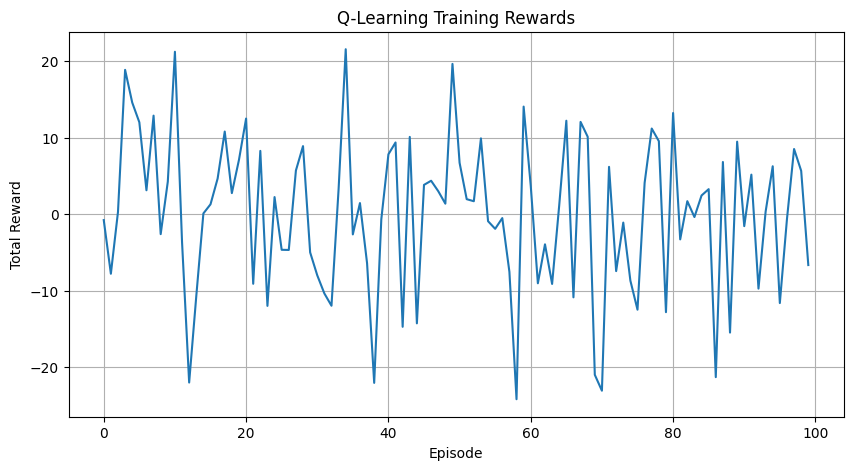

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.title("Q-Learning Training Rewards")

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.grid(True)

plt.show()

In [16]:
print(Q_table)

[[ 0.44429854  0.54495985  0.50068011]
 [ 0.18582689  0.59369757  0.61793055]
 [ 0.49926     0.36469417  0.18514477]
 [-0.10683095  0.31452298  0.67288705]
 [ 0.2442739   0.64453098  0.1473606 ]
 [ 0.50701555  0.41780497  0.34784777]
 [ 0.36359108  0.33516596  0.52790373]
 [ 0.36878566  0.31074273  0.53886797]
 [ 0.12297555  0.74114552  0.32141181]
 [ 0.25491943  0.59859121  0.24386026]
 [ 0.7638381   0.53112158  0.37597825]
 [ 0.02667154  0.70145261  1.20181898]
 [ 0.00147364  0.61571291  0.20782097]
 [ 1.14976871  0.1220993   0.52836242]
 [ 0.61637724  0.16936169  0.61792823]
 [ 0.76201802  0.6840449   0.60218979]
 [ 0.25977552  0.87206436  0.31563402]
 [ 0.70998289  0.58234435  0.64833989]
 [ 0.45564261  0.77553139  0.50758142]
 [ 0.56469277  0.77896674  0.63714885]
 [ 0.23864683 -0.12177533  0.38043128]
 [ 0.41836213  0.31144567  0.6913192 ]
 [ 0.14248811  0.25700522  0.71952393]
 [ 0.36063389  0.56074721  0.2843922 ]
 [ 0.46361474  0.02144282  0.74410985]
 [ 0.47424513  0.15304263

In [18]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/cloud_performance_features.csv")

In [19]:
state_features = [
    "cpu_usage",
    "memory_usage",
    "network_traffic",
    "power_consumption"
]

In [20]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class CloudEnvironment(gym.Env):

    def __init__(self, dataframe):

        super().__init__()

        self.df = dataframe.reset_index(drop=True)

        self.current_step = 0

        self.features = [
            "cpu_usage",
            "memory_usage",
            "network_traffic",
            "power_consumption"
        ]

        self.observation_space = spaces.Box(
            low=0,
            high=1000,
            shape=(4,),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(3)

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0

        state = self.df.loc[self.current_step, self.features].values

        return state.astype(np.float32), {}

    def step(self, action):

        row = self.df.iloc[self.current_step]

        execution_time = row["execution_time"]
        energy_efficiency = row["energy_efficiency"]
        power = row["power_consumption"]

        # Reward Function
        reward = (
            energy_efficiency
            - (execution_time / 100)
            - (power / 500)
        )

        self.current_step += 1

        terminated = self.current_step >= len(self.df) - 1

        truncated = False

        if terminated:
            next_state = np.zeros(4)

        else:
            next_state = self.df.loc[
                self.current_step,
                self.features
            ].values

        return (
            next_state.astype(np.float32),
            reward,
            terminated,
            truncated,
            {}
        )

In [21]:
env = CloudEnvironment(df)

In [22]:
state, info = env.reset()

print(state)

[ 54.88135  78.95086 164.77597 287.809  ]


In [23]:
next_state, reward, terminated, truncated, info = env.step(1)

print("Next State:", next_state)
print("Reward:", reward)

Next State: [ 71.518936  29.901882 500.0076   362.27356 ]
Reward: -0.7154847085698656


In [24]:
env = CloudEnvironment(df)

In [25]:
import numpy as np

num_states = 100
num_actions = env.action_space.n

Q_table = np.zeros((num_states, num_actions))

print(Q_table.shape)

(100, 3)


In [26]:
alpha = 0.1          # Learning rate
gamma = 0.95         # Discount factor
epsilon = 1.0        # Exploration rate

episodes = 100
max_steps = 500

In [27]:
episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    for step in range(max_steps):

        # Convert the first state value into a table index
        state_index = int(state[0]) % num_states

        # Epsilon-greedy policy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_table[state_index])

        next_state, reward, terminated, truncated, info = env.step(action)

        next_state_index = int(next_state[0]) % num_states

        # Q-learning update
        Q_table[state_index, action] += alpha * (
            reward
            + gamma * np.max(Q_table[next_state_index])
            - Q_table[state_index, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    epsilon = max(0.01, epsilon * 0.995)

    episode_rewards.append(total_reward)

print("Training Complete!")

Training Complete!


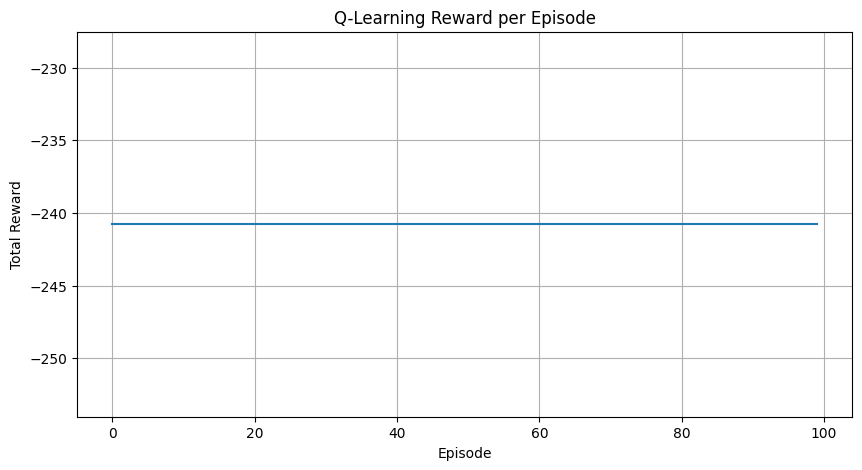

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(episode_rewards)
plt.title("Q-Learning Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

In [29]:
print(Q_table[:10])

[[-3.6371052  -3.50077978 -3.57570056]
 [-4.48656986 -4.59811394 -4.54035066]
 [-5.00679094 -4.91767048 -4.90494668]
 [-5.56632292 -5.45988609 -5.55908556]
 [-4.17382531 -4.17563053 -4.13841748]
 [-5.21388981 -5.17769811 -5.28655702]
 [-5.00377295 -5.04740412 -4.63519467]
 [-5.17640862 -5.19715915 -5.16207094]
 [-4.77556596 -4.95187046 -4.77053448]
 [-5.3252768  -5.17138008 -5.18602851]]
